How to Approach Machine Learning Projects

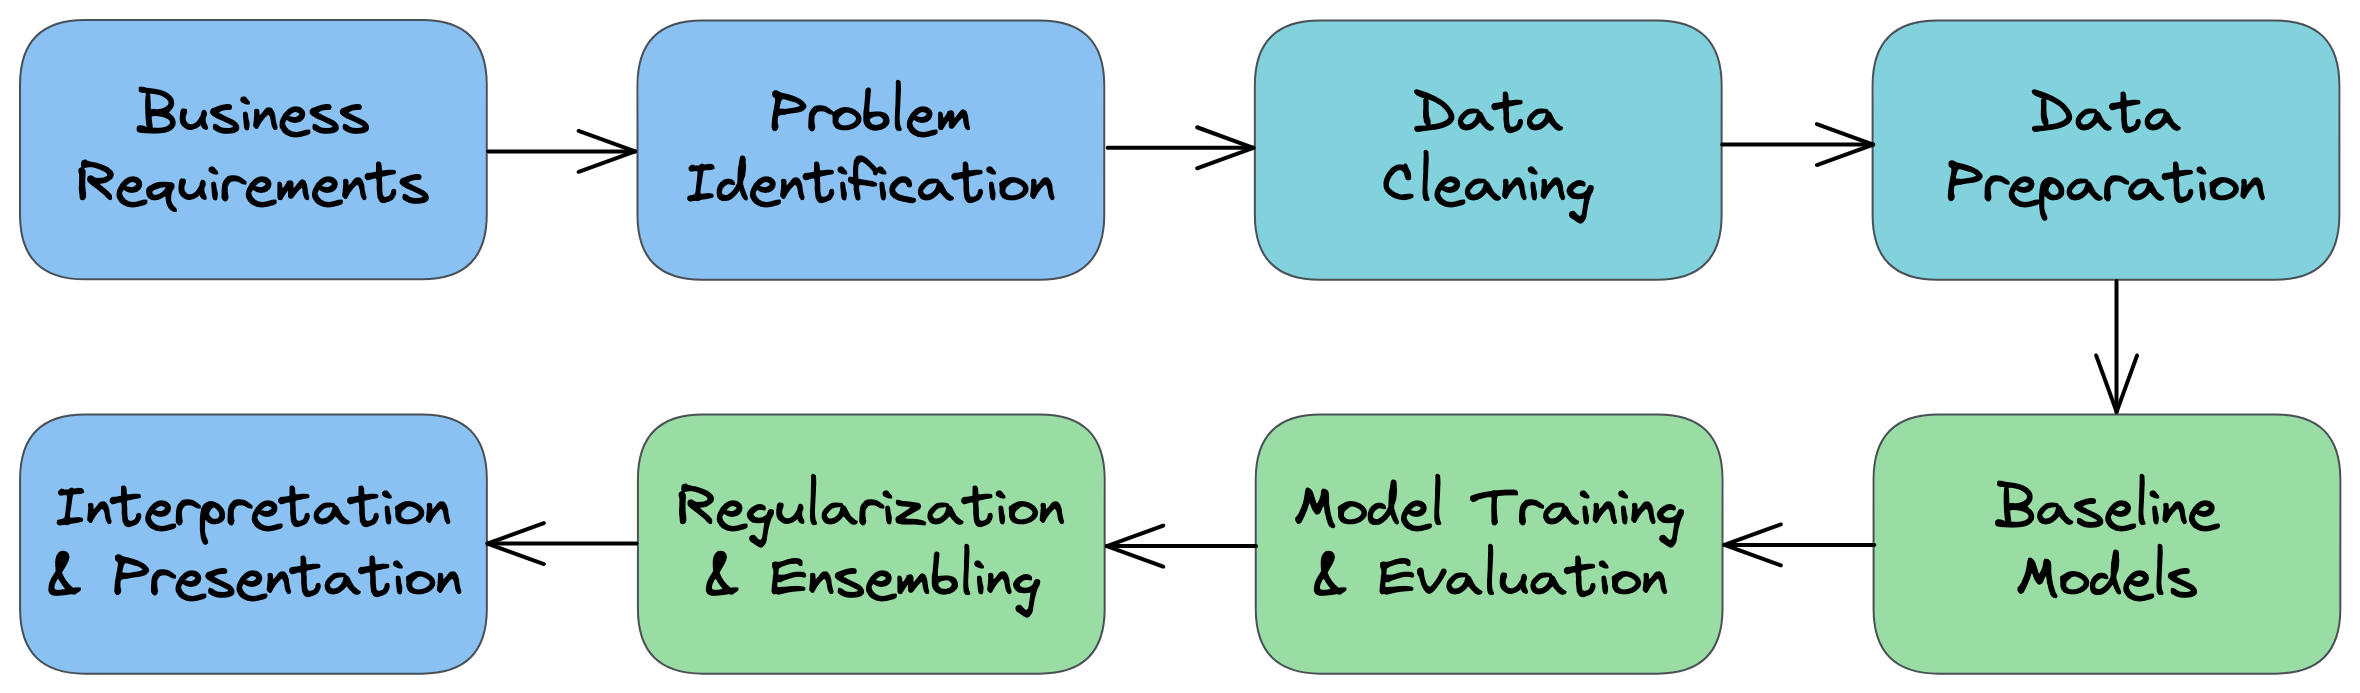

In this tutorial, we'll explore a step-by-step process for approaching ML problems:

1. Understand the business requirements and the nature of the available data.
2. Classify the problem as supervised/unsupervised and regression/classification.
3. Download, clean & explore the data and create new features that may improve models.
4. Create training/test/validation sets and prepare the data for training ML models.
5. Create a quick & easy baseline model to evaluate and benchmark future models.
6. Pick a modeling strategy, train a model, and tune hyperparameters to achieve optimal fit.
7. Experiment and combine results from multiple strategies to get a better result.
8. Interpret models, study individual predictions, and present your findings. 


In [1]:
%pip install numpy pandas-profiling matplotlib plotly seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install opendatasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os 
import jovian
import matplotlib
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

<IPython.core.display.Javascript object>

## Step 2 - 4Classify the problem as supervised/unsupervised & regression/classification

<img src="https://i.imgur.com/rqt2A7F.png" width="640">

Here's the landscape of machine learning([source](https://medium.datadriveninvestor.com/machine-learning-in-10-minutes-354d83e5922e)):

<img src="https://miro.medium.com/max/842/1*tlQwBmbL6RkuuFq8OPJofw.png" width="640">



Here are the topics in machine learning that we're studying in this course ([source](https://vas3k.com/blog/machine_learning/)): 

<img src="https://i.imgur.com/VbVFAsg.png" width="640">


## Step 3 - Download, clean & explore the data and create new features

<img src="https://i.imgur.com/0f7foe7.png" width="640">

### Downloading Data

There may be different sources to get the data:

* CSV files
* SQL databases
* Raw File URLs
* Kaggle datasets 
* Google Drive
* Dropbox
* etc.

Identify the right tool/library to get the data. 

For the Rossmann Store Sales prediction dataset, we'll use the `opendatasets` library. Make sure to [accept the competition rules](https://www.kaggle.com/c/rossmann-store-sales/rules) before executing the following cell.

In [4]:
import opendatasets as od

url = "https://www.kaggle.com/c/rossmann-store-sales"

In [5]:
od.download(url)

Skipping, found downloaded files in ".\rossmann-store-sales" (use force=True to force download)


In [6]:
import os
os.listdir('rossmann-store-sales')

['sample_submission.csv', 'store.csv', 'test.csv', 'train.csv']

In [7]:
import pandas as pd
ross_df = pd.read_csv('./rossmann-store-sales/train.csv', low_memory=False)

In [8]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [9]:
store_df = pd.read_csv('./rossmann-store-sales/store.csv')
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [10]:
merged_df = ross_df.merge(store_df, on='Store', how='left')
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [11]:
merged_df.shape

(1017209, 18)

In [12]:
test_df = pd.read_csv('./rossmann-store-sales/test.csv', low_memory=False)
test_df.shape

(41088, 8)

In [13]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [39]:
merged_test_df = test_df.merge(store_df, on='Store', how='left')    

In [15]:
merged_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


## You can merge as much data as u want...
## In example think maybe financial data of the compettitors is imortant so can merged that AND COMPARE its completely depends on what u think about the data andd how u understood that..

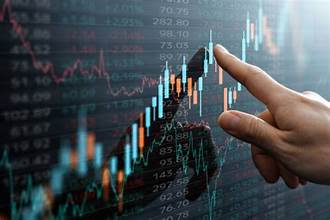

In [16]:
merged_test_df.shape

(41088, 17)

### Cleaning Data

The first step is to check the column data types and identify if there are any null values.

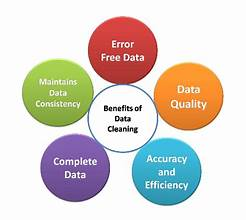

In [17]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

When some data is broken it best to talk to the owner itself for missing data or what he  nedds according  to that adjust the missing values...

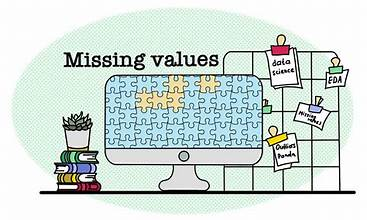

In [20]:
round(merged_df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.43,321.91,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,4.00,2.00,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.82,3849.93,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.15,464.41,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.83,0.38,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.38,0.49,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.18,0.38,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.09,7715.32,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.22,3.21,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.69,5.99,1900.0,2006.0,2010.0,2013.0,2015.0


In [21]:
merged_df.duplicated().sum()

np.int64(0)

Let's also parse the date column

In [24]:
merged_df["Date"] = pd.to_datetime(merged_df["Date"])

In [25]:
merged_test_df["Date"] = pd.to_datetime(merged_test_df["Date"])

In [26]:
merged_df.Date.min(), merged_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [27]:
merged_test_df.Date.min(), merged_test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

### Exploratory Data Analysis and Visualization

Objectives of exploratory data analysis:

- Study the distributions of individual columns (uniform, normal, exponential)
- Detect anomalies or errors in the data (e.g. missing/incorrect values)
- Study the relationship of target column with other columns (linear, non-linear etc.)
- Gather insights about the problem and the dataset
- Come up with ideas for preprocessing and feature engineering



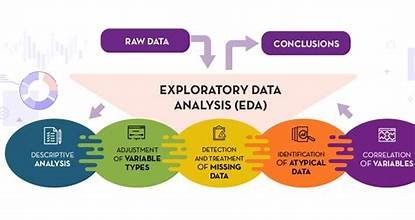

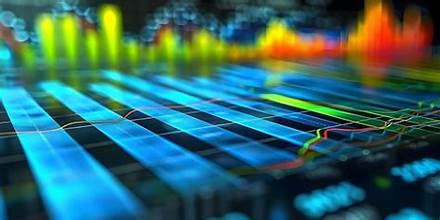

<Axes: xlabel='Sales', ylabel='Count'>

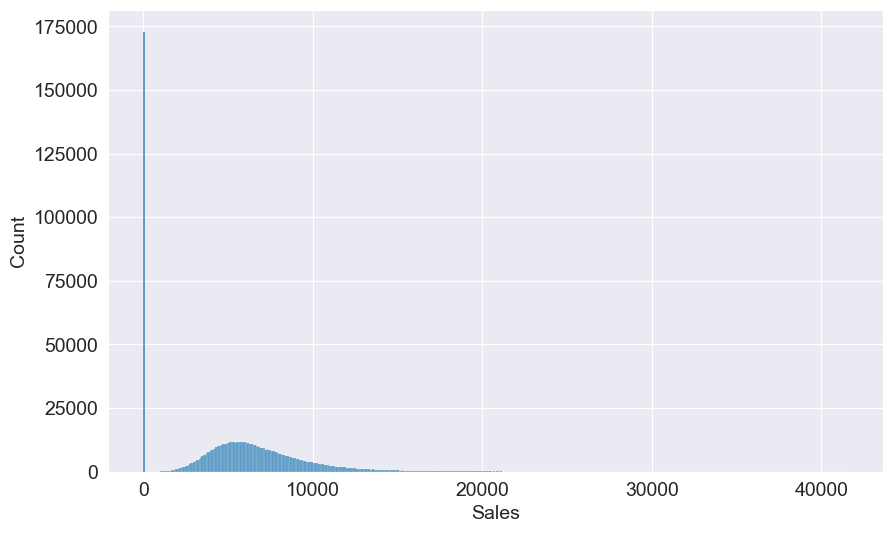

In [29]:
sns.histplot(data = merged_df, x = 'Sales')

Can you explain why the sales are 0 on so many dates? 

Let's check if this is because the store was closed.

In [31]:
merged_df.Open.value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [32]:
merged_df.value_counts('Open')

Open
1    844392
0    172817
Name: count, dtype: int64

In [35]:
merged_df.Sales.value_counts()

Sales
0        172871
5674        215
5558        197
5483        196
6214        195
          ...  
982           1
1173          1
1090          1
1338          1
18841         1
Name: count, Length: 21734, dtype: int64

In [36]:
merged_df = merged_df[merged_df.Open == 1].copy()

<Axes: xlabel='Sales', ylabel='Count'>

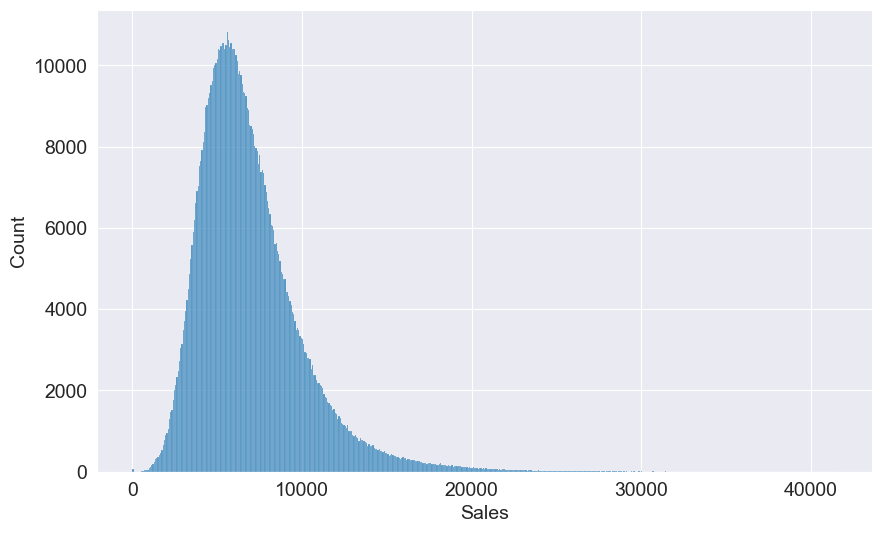

In [38]:
sns.histplot(data = merged_df, x = 'Sales')

Let's explore some other columns

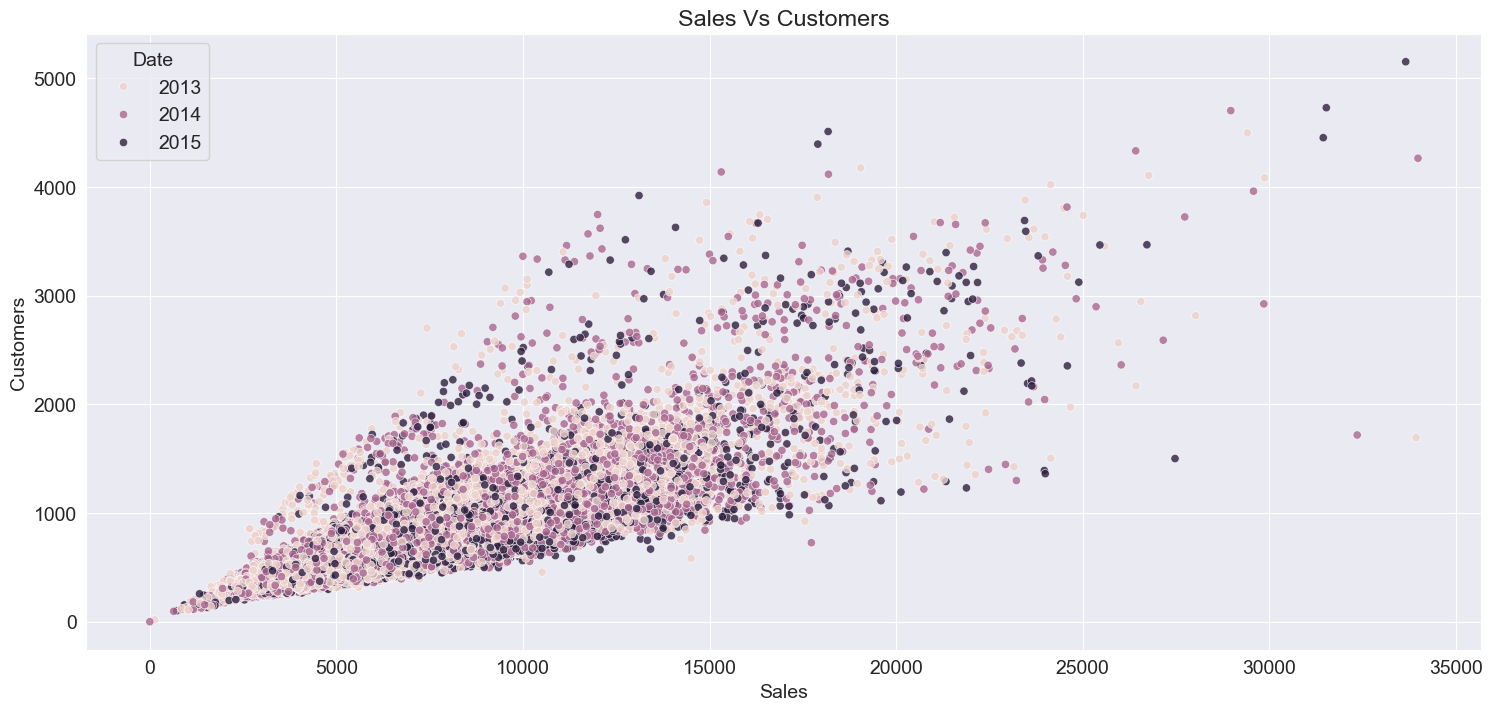

In [40]:
plt.figure(figsize=(18,8))
temp_df = merged_df.sample(40000)
sns.scatterplot(x=temp_df.Sales, y=temp_df.Customers, hue=temp_df.Date.dt.year, alpha=0.8)
plt.title("Sales Vs Customers")
plt.show()

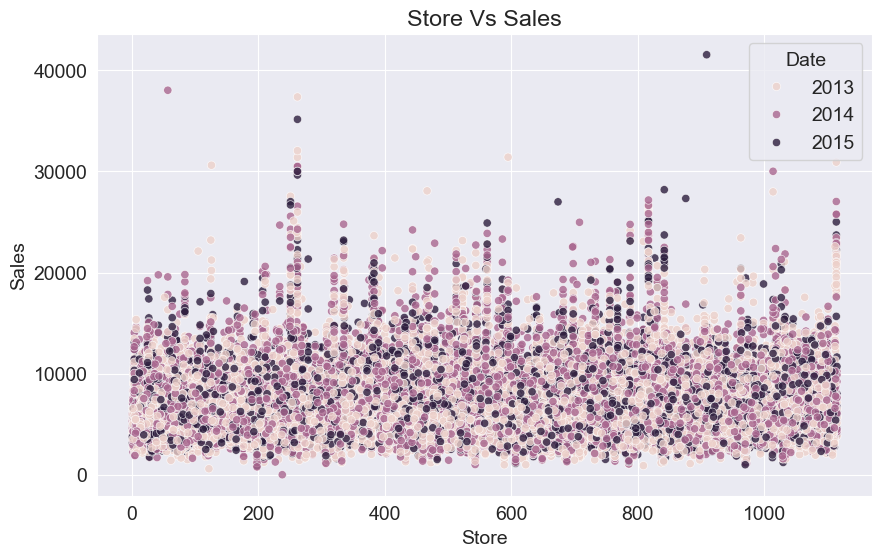

In [41]:
plt.Figure(figsize=(18,8))
temp_df = merged_df.sample(40000)
sns.scatterplot(x=temp_df.Store, y=temp_df.Sales, hue=temp_df.Date.dt.year, alpha=0.8)
plt.title("Store Vs Sales")
plt.show()

In [43]:
import plotly.express as px

temp_df = merged_df.sample(40000)

fig = px.scatter(
    temp_df,
    x="Store",
    y="Sales",
    color=temp_df["Date"].dt.year.astype(str),
    hover_data=["Date", "Sales", "Customers"]
)

fig.show()

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

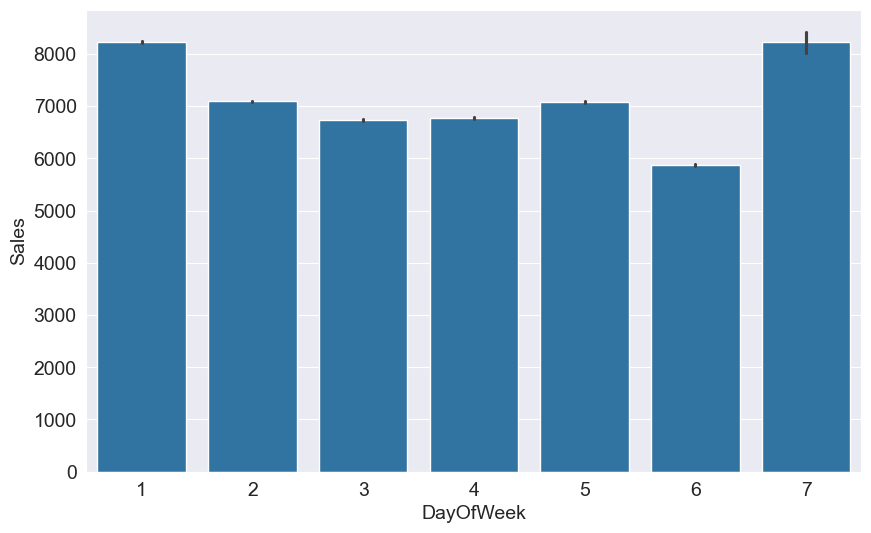

In [42]:
sns.barplot(data=merged_df, x='DayOfWeek', y='Sales')

In [44]:
import plotly.express as px

day_sales = merged_df.groupby('DayOfWeek')['Sales'].mean().reset_index()
fig = px.bar(
    day_sales,
    x='DayOfWeek',
    y='Sales',
    title='Average Sales by Day of Week',
    hover_data=['Sales']
)

fig.show()

<Axes: xlabel='Promo', ylabel='Sales'>

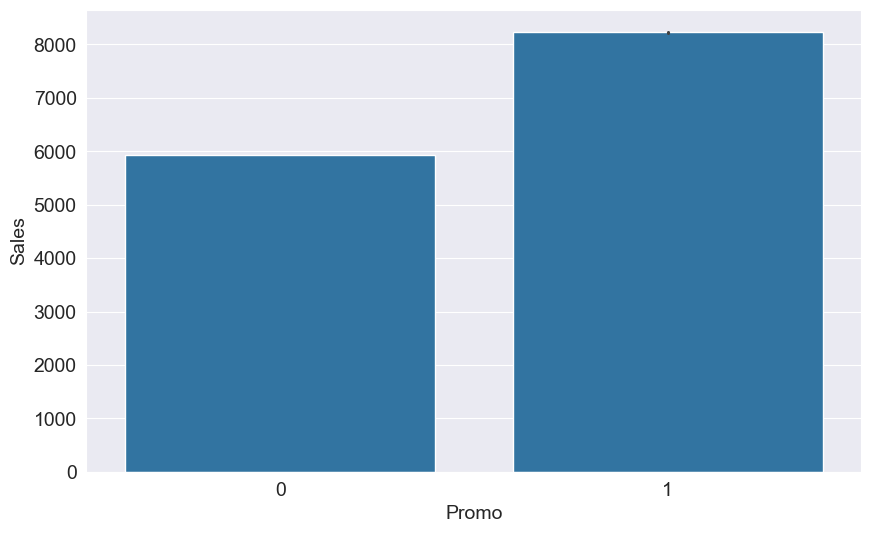

In [45]:
sns.barplot(data=merged_df, x='Promo', y='Sales')

In [46]:
import plotly.express as px

promo_sales = merged_df.groupby('Promo')['Sales'].mean().reset_index()
fig = px.bar(
    promo_sales,
    x='Promo',
    y='Sales',
    title='Average Sales by Promo',
    hover_data=['Sales']
)

fig.show()

In [48]:
# Correlate Sales only with numeric columns
merged_df.select_dtypes(include='number').corr()['Sales'].sort_values(ascending=False)

Sales                        1.000000
Customers                    0.823597
Promo                        0.368145
Promo2SinceWeek              0.095311
SchoolHoliday                0.038617
CompetitionOpenSinceYear     0.016101
Store                        0.007710
Promo2SinceYear             -0.034713
CompetitionDistance         -0.036396
CompetitionOpenSinceMonth   -0.043489
Promo2                      -0.127596
DayOfWeek                   -0.178736
Open                              NaN
Name: Sales, dtype: float64

Top numeric relationships with Sales (by absolute correlation):


,corr_with_sales
Customers,0.823597
Promo,0.368145
DayOfWeek,-0.178736
Promo2,-0.127596
Promo2SinceWeek,0.095311
CompetitionOpenSinceMonth,-0.043489
SchoolHoliday,0.038617
CompetitionDistance,-0.036396
Promo2SinceYear,-0.034713
CompetitionOpenSinceYear,0.016101


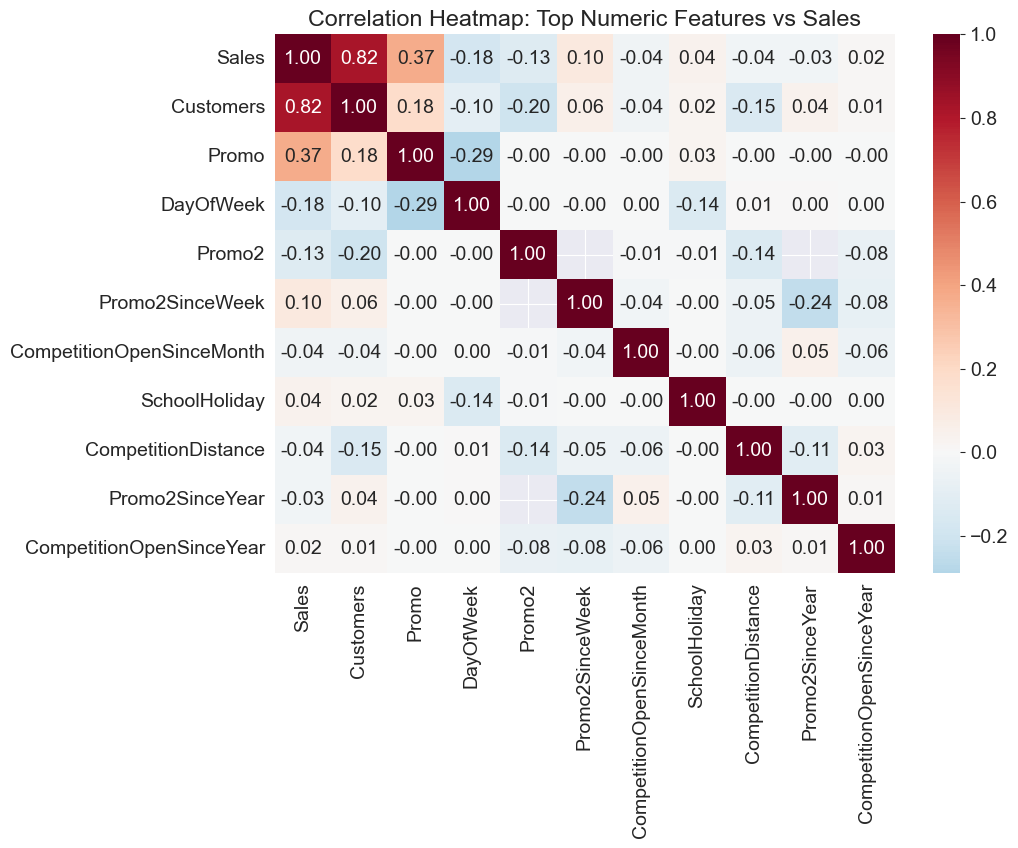


Category impact on Sales: StateHoliday


,mean,median,count
StateHoliday,,,
b,9887.889655,8423.0,145
c,9743.746479,8397.0,71
a,8487.471182,7556.0,694
0,6953.515034,6368.0,843482


C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_8996\2036319236.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




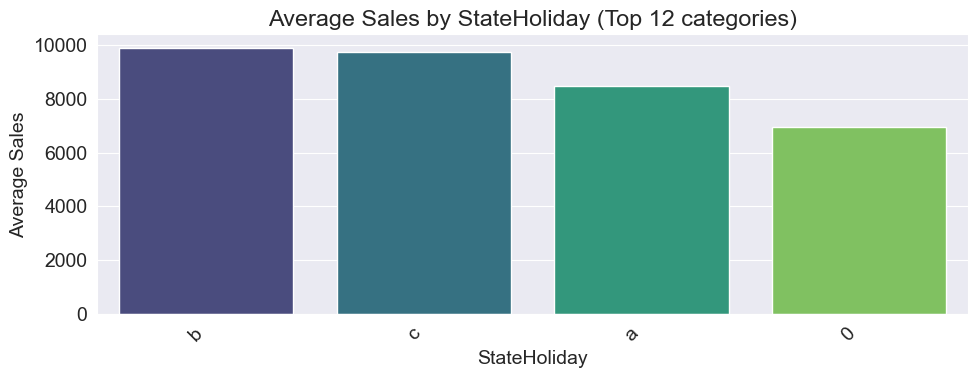


Category impact on Sales: StoreType


,mean,median,count
StoreType,,,
b,10231.407505,9130.0,15563
c,6932.512755,6407.0,112978
a,6925.167661,6285.0,457077
d,6822.141881,6395.0,258774


C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_8996\2036319236.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




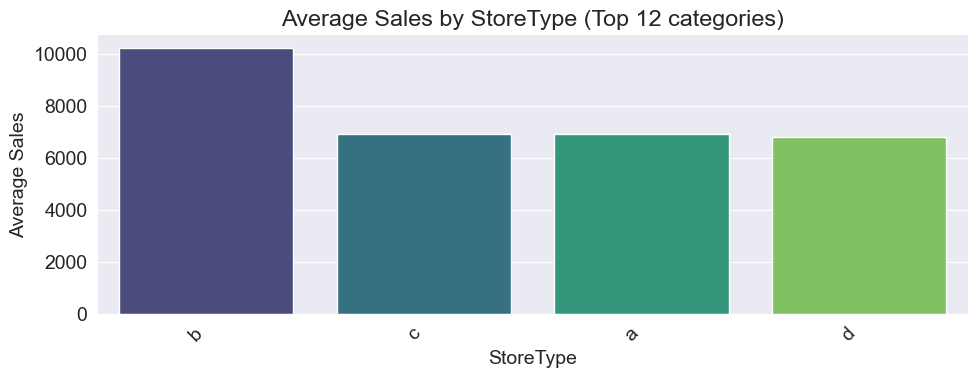


Category impact on Sales: Assortment


,mean,median,count
Assortment,,,
b,8639.346322,8081.0,8212
c,7300.526339,6675.0,391271
a,6621.017039,6082.0,444909


C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_8996\2036319236.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




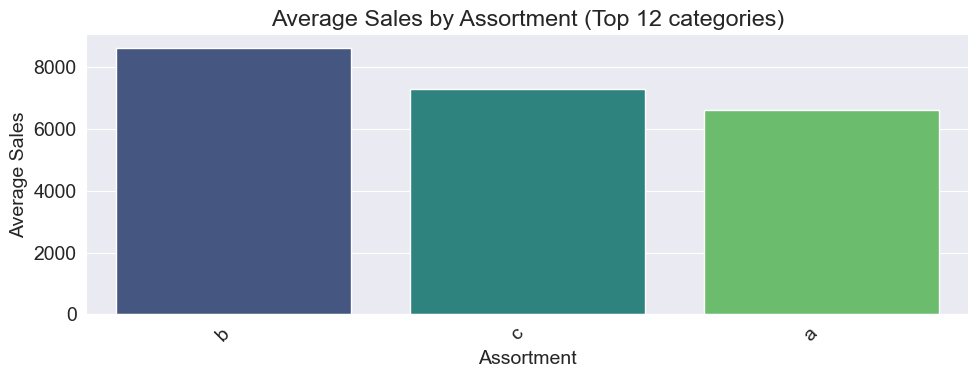


Category impact on Sales: PromoInterval


,mean,median,count
PromoInterval,,,
NaN,7350.557935,6685.0,423307
"Jan,Apr,Jul,Oct",6725.978932,6215.0,242411
"Feb,May,Aug,Nov",6426.907994,6002.0,98005
"Mar,Jun,Sept,Dec",6214.501209,5754.0,80669


C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_8996\2036319236.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




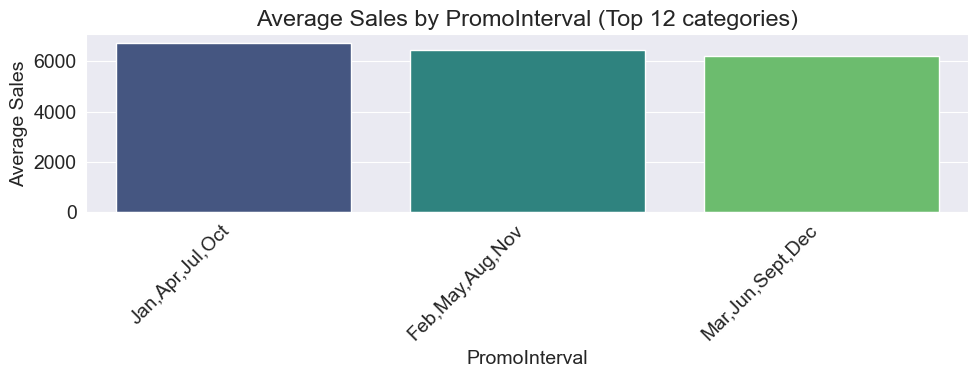

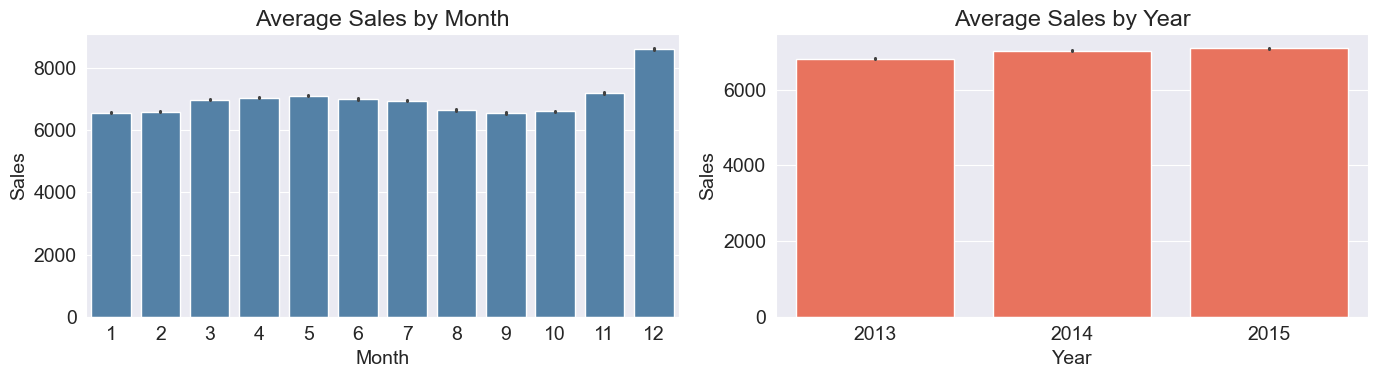

Analysis complete: numeric, categorical, and date-based relationships explored.


In [50]:
# EXERCISE: Analyze how other columns are related to Sales
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'Sales'

# 1) Numeric columns vs target (correlation)
numeric_cols = merged_df.select_dtypes(include='number').columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

num_corr = merged_df[[target_col] + numeric_cols].corr()[target_col].drop(target_col)
num_corr_sorted = num_corr.reindex(num_corr.abs().sort_values(ascending=False).index)

print('Top numeric relationships with Sales (by absolute correlation):')
display(num_corr_sorted.head(12).to_frame('corr_with_sales'))

# Heatmap for top numeric columns
top_num_cols = num_corr_sorted.head(10).index.tolist()
plt.figure(figsize=(10, 7))
sns.heatmap(
    merged_df[[target_col] + top_num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0
 )
plt.title('Correlation Heatmap: Top Numeric Features vs Sales')
plt.show()

# 2) Categorical columns vs target (mean sales by category)
cat_cols = merged_df.select_dtypes(include=['object', 'category']).columns.tolist()

if not cat_cols:
    print('No categorical columns found for grouped analysis.')
else:
    # Keep only manageable cardinality columns for clear plots
    cat_cols = [c for c in cat_cols if merged_df[c].nunique(dropna=False) <= 20]

    if not cat_cols:
        print('Categorical columns have high cardinality; skipping category plots.')
    else:
        for col in cat_cols:
            summary = (
                merged_df.groupby(col, dropna=False)[target_col]
                .agg(['mean', 'median', 'count'])
                .sort_values('mean', ascending=False)
            )

            print(f'\nCategory impact on Sales: {col}')
            display(summary.head(12))

            plt.figure(figsize=(10, 4))
            sns.barplot(
                data=summary.reset_index().head(12),
                x=col,
                y='mean',
                palette='viridis'
            )
            plt.title(f'Average Sales by {col} (Top 12 categories)')
            plt.xticks(rotation=45, ha='right')
            plt.ylabel('Average Sales')
            plt.tight_layout()
            plt.show()

# 3) Date-derived feature relationships (if Date exists)
if 'Date' in merged_df.columns and np.issubdtype(merged_df['Date'].dtype, np.datetime64):
    date_df = merged_df.copy()
    date_df['Month'] = date_df['Date'].dt.month
    date_df['Year'] = date_df['Date'].dt.year

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=date_df, x='Month', y=target_col, estimator=np.mean, ax=axes[0], color='steelblue')
    axes[0].set_title('Average Sales by Month')

    sns.barplot(data=date_df, x='Year', y=target_col, estimator=np.mean, ax=axes[1], color='tomato')
    axes[1].set_title('Average Sales by Year')

    plt.tight_layout()
    plt.show()

print('Analysis complete: numeric, categorical, and date-based relationships explored.')